# ch276 — Bias and Variance

*(Formalizes the error decomposition from ch271; uses expected value from ch249; connects to gradient descent from ch213)*

## 1. The Fundamental Question

When a model makes a prediction $\hat{f}(x)$ for a target $y$, the error has structure. It is not just random noise. It decomposes into two fundamentally different components with different causes and different remedies.

This decomposition is one of the most important results in statistics and ML.

---

## 2. The Bias-Variance Decomposition

Assume the true relationship is:
$$y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

We train a model $\hat{f}$ on a sample. The expected squared error at point $x$ is:

$$E[(y - \hat{f}(x))^2] = \underbrace{(f(x) - E[\hat{f}(x)])^2}_{\text{Bias}^2} + \underbrace{\text{Var}(\hat{f}(x))}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

- **Bias**: the gap between the average prediction and the true value. Caused by model being too simple (underfitting).
- **Variance**: how much the prediction fluctuates across different training sets. Caused by model being too complex (overfitting).
- **Irreducible noise**: $\sigma^2$ — inherent randomness in the data. Cannot be reduced by any model.

C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:1

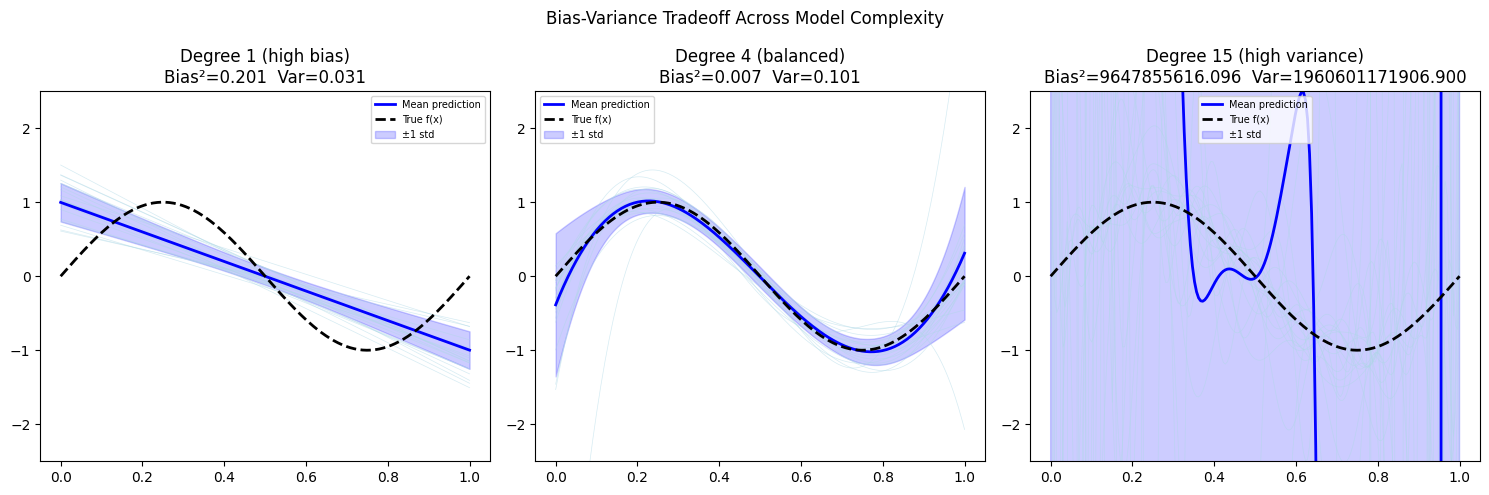

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# True function
def true_f(x): return np.sin(2 * np.pi * x)

sigma = 0.3
x_test = np.linspace(0, 1, 200)
n_train = 20
n_sims  = 200

def fit_polynomial(x_tr, y_tr, x_te, degree):
    """Fit polynomial of given degree and predict on x_te."""
    coeffs = np.polyfit(x_tr, y_tr, degree)
    return np.polyval(coeffs, x_te)

# Collect predictions across many training sets
predictions = {deg: [] for deg in [1, 4, 15]}

for _ in range(n_sims):
    x_tr = rng.uniform(0, 1, n_train)
    y_tr = true_f(x_tr) + rng.normal(0, sigma, n_train)
    for deg in predictions:
        try:
            pred = fit_polynomial(x_tr, y_tr, x_test, deg)
            predictions[deg].append(pred)
        except Exception:
            pass

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Degree 1 (high bias)', 'Degree 4 (balanced)', 'Degree 15 (high variance)']

for ax, (deg, preds), label in zip(axes, predictions.items(), labels):
    preds = np.array(preds)  # shape: (n_sims, len(x_test))
    mean_pred = preds.mean(axis=0)
    std_pred  = preds.std(axis=0)

    # Show a few individual fits
    for p in preds[:20]:
        ax.plot(x_test, p, color='lightblue', lw=0.5, alpha=0.5)
    ax.plot(x_test, mean_pred,       color='blue',  lw=2, label='Mean prediction')
    ax.plot(x_test, true_f(x_test),  color='black', lw=2, ls='--', label='True f(x)')
    ax.fill_between(x_test, mean_pred - std_pred, mean_pred + std_pred,
                    alpha=0.2, color='blue', label='±1 std')

    bias_sq  = np.mean((mean_pred - true_f(x_test))**2)
    variance = np.mean(std_pred**2)
    ax.set_title(f'{label}\nBias²={bias_sq:.3f}  Var={variance:.3f}')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=7)

plt.suptitle('Bias-Variance Tradeoff Across Model Complexity', fontsize=12)
plt.tight_layout()
plt.show()

## 3. The Tradeoff

Bias and variance move in opposite directions as model complexity increases:

- **Increase complexity** → bias decreases, variance increases
- **Decrease complexity** → bias increases, variance decreases

Total error = Bias² + Variance + σ²

The optimal model minimizes total error, not just one component.

C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:16: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_tr, y_tr, degree)
C:\Users\user\AppData\Local\Temp\ipykernel_14548\2327926751.py:1

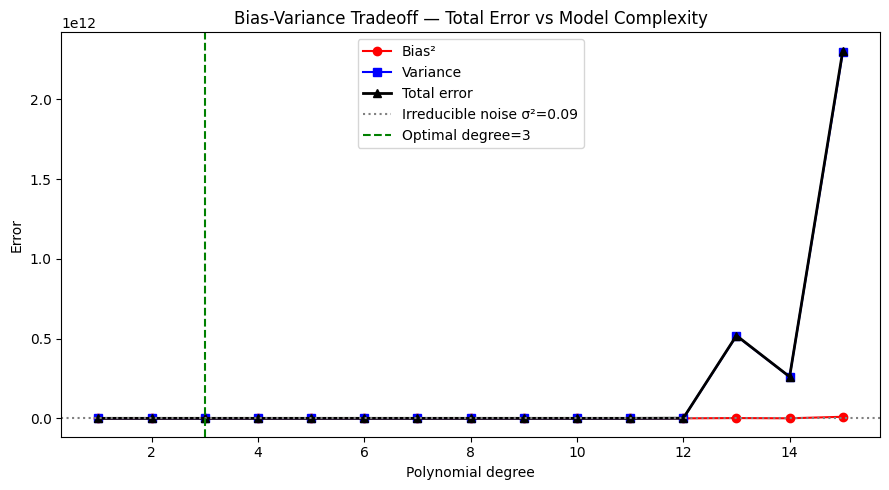

In [2]:
degrees = list(range(1, 16))
bias_sq_by_deg = []
var_by_deg     = []

for deg in degrees:
    preds_deg = []
    for _ in range(300):
        x_tr = rng.uniform(0, 1, n_train)
        y_tr = true_f(x_tr) + rng.normal(0, sigma, n_train)
        try:
            p = fit_polynomial(x_tr, y_tr, x_test, deg)
            if np.all(np.isfinite(p)):
                preds_deg.append(p)
        except Exception:
            pass
    if preds_deg:
        preds_deg = np.array(preds_deg)
        mean_pred = preds_deg.mean(axis=0)
        bias_sq_by_deg.append(np.mean((mean_pred - true_f(x_test))**2))
        var_by_deg.append(np.mean(preds_deg.var(axis=0)))
    else:
        bias_sq_by_deg.append(np.nan)
        var_by_deg.append(np.nan)

bias_sq = np.array(bias_sq_by_deg)
var_arr = np.array(var_by_deg)
total   = bias_sq + var_arr + sigma**2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, bias_sq, 'o-', color='red',    label='Bias²')
ax.plot(degrees, var_arr, 's-', color='blue',   label='Variance')
ax.plot(degrees, total,   '^-', color='black',  label='Total error', lw=2)
ax.axhline(sigma**2, color='gray', ls=':', label=f'Irreducible noise σ²={sigma**2:.2f}')
best_deg = degrees[np.nanargmin(total)]
ax.axvline(best_deg, color='green', ls='--', label=f'Optimal degree={best_deg}')
ax.set_xlabel('Polynomial degree'); ax.set_ylabel('Error')
ax.set_title('Bias-Variance Tradeoff — Total Error vs Model Complexity')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Estimator Bias

The bias-variance framework applies to estimators (statistics computed from samples), not just models.

An estimator $\hat{\theta}$ of parameter $\theta$ has:
- **Bias**: $B(\hat{\theta}) = E[\hat{\theta}] - \theta$
- **Mean Squared Error (MSE)**: $\text{MSE}(\hat{\theta}) = \text{Bias}^2(\hat{\theta}) + \text{Var}(\hat{\theta})$

In [3]:
# Biased vs unbiased variance estimators
true_sigma2 = 25.0
n_small     = 5
n_sims_est  = 10000

biased_estimates   = []
unbiased_estimates = []

for _ in range(n_sims_est):
    sample = rng.normal(0, np.sqrt(true_sigma2), n_small)
    biased_estimates.append(np.var(sample, ddof=0))    # divide by n
    unbiased_estimates.append(np.var(sample, ddof=1))  # divide by n-1

biased   = np.array(biased_estimates)
unbiased = np.array(unbiased_estimates)

print(f"True variance:              {true_sigma2:.2f}")
print(f"E[biased estimator]:        {biased.mean():.2f}  (bias = {biased.mean()-true_sigma2:.2f})")
print(f"E[unbiased estimator]:      {unbiased.mean():.2f}  (bias ≈ {unbiased.mean()-true_sigma2:.2f})")
print(f"MSE biased:                 {((biased - true_sigma2)**2).mean():.2f}")
print(f"MSE unbiased:               {((unbiased - true_sigma2)**2).mean():.2f}")
print()
print("Interesting: for n=5, the biased estimator has LOWER MSE than the unbiased one.")
print("Bias-variance tradeoff applies to estimators too.")

True variance:              25.00
E[biased estimator]:        19.84  (bias = -5.16)
E[unbiased estimator]:      24.80  (bias ≈ -0.20)
MSE biased:                 225.23
MSE unbiased:               310.36

Interesting: for n=5, the biased estimator has LOWER MSE than the unbiased one.
Bias-variance tradeoff applies to estimators too.


## 5. What Comes Next

The bias-variance decomposition explains *why* we see the patterns we see in model performance. **ch283 — Overfitting** examines this in the context of training vs test error. **ch284 — Cross Validation** provides the computational procedure for estimating the variance component empirically.

In **ch296 — Optimization Methods**, regularization will emerge as a technique that deliberately introduces a small amount of bias to achieve a large reduction in variance — a direct application of the tradeoff analyzed here.